## Train_Data

In [1]:
# STEP 1: IMPORT LIBRARIES
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler

# Deep Learning
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam

In [2]:
# STEP 2: LOAD DATASET
data = pd.read_csv(r"C:\Users\Chekk\OneDrive\Desktop\Major_Project\Machine_Learning_Project\train_FD001.txt",sep=" ",header=None)

# Remove extra columns
data.drop(columns=[26, 27], inplace=True)

# Assign column names
columns = [
    'unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50',
    'P2','P15','P30','Nf','Nc','epr','Ps30','phi','NRf','NRc','BPR','farB',
    'htBleed','Nf_dmd','PCNfR_dmd','W31','W32'
]

data.columns = columns

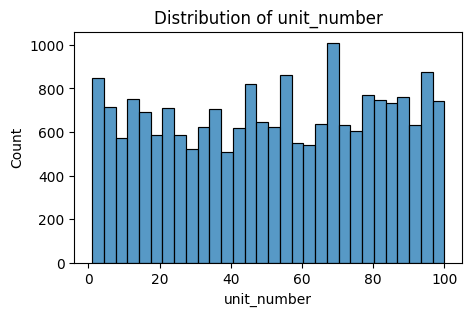

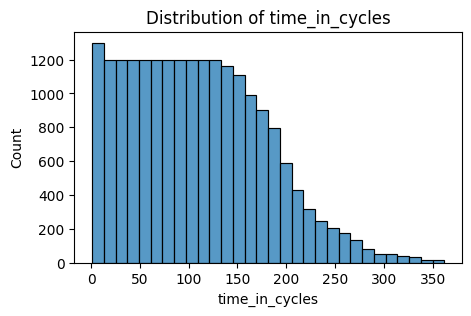

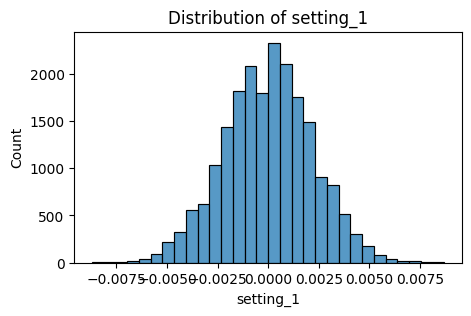

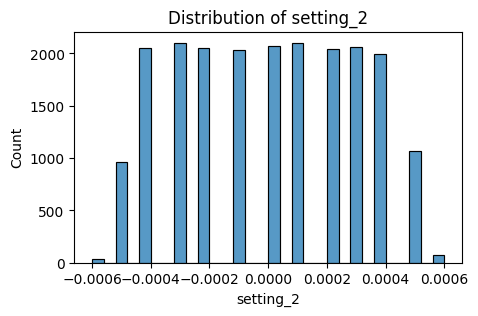

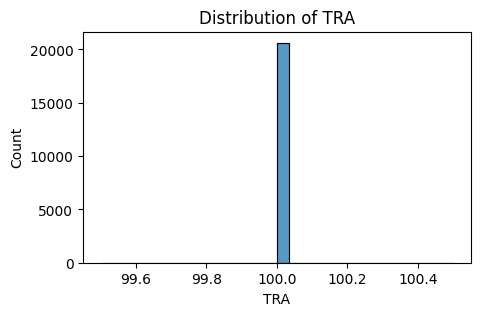

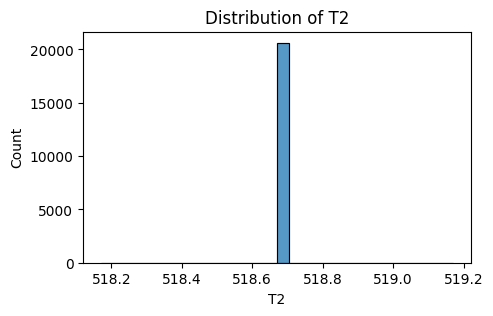

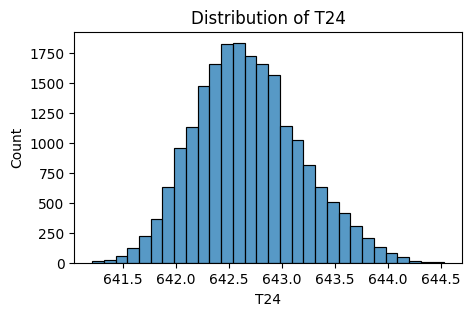

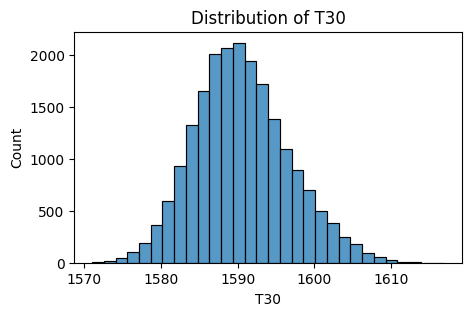

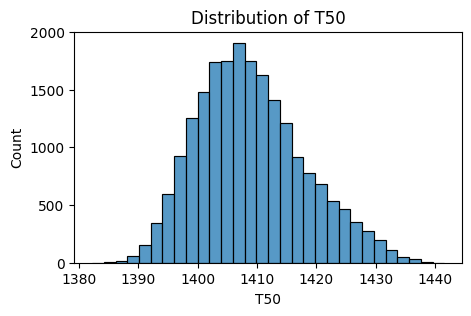

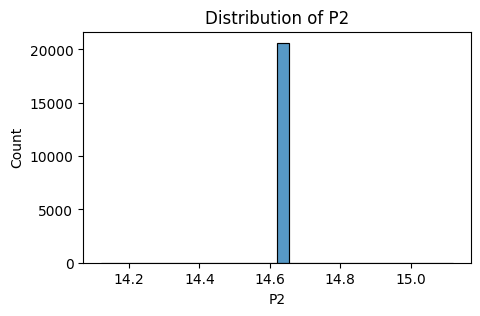

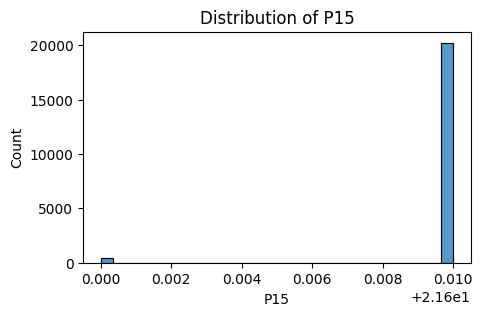

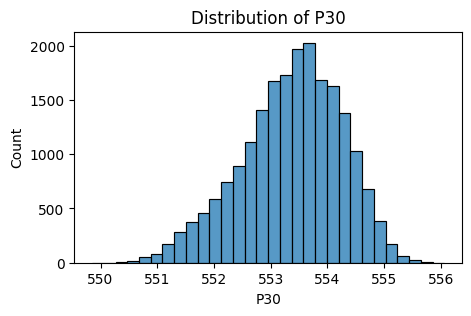

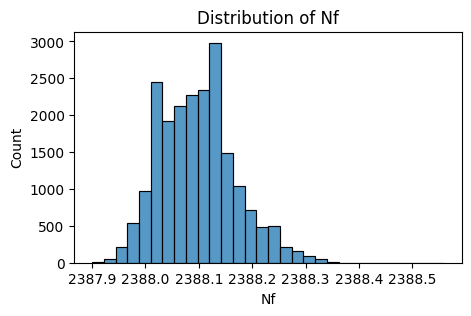

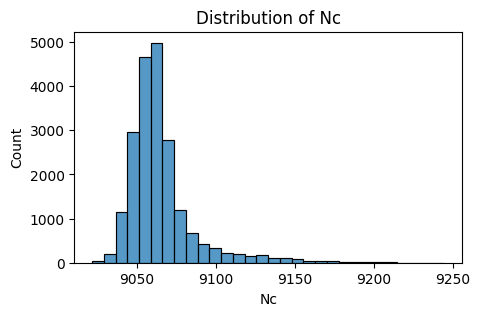

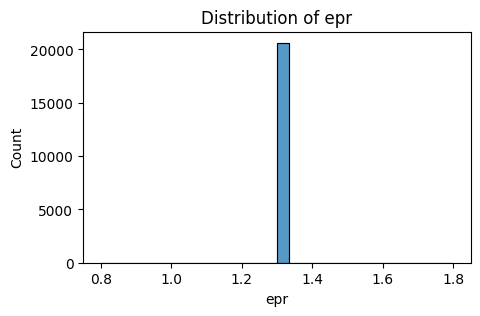

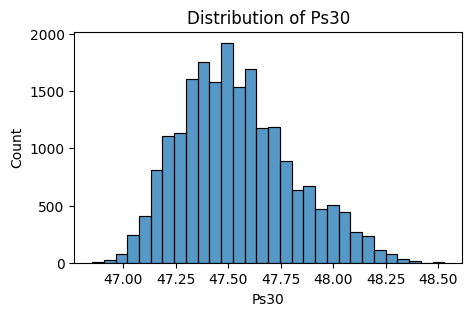

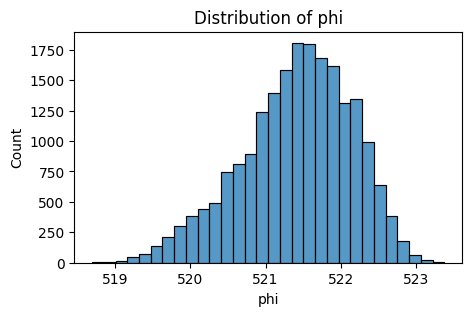

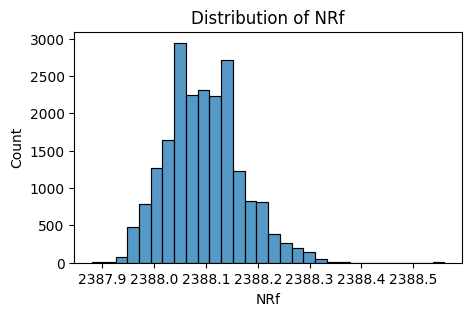

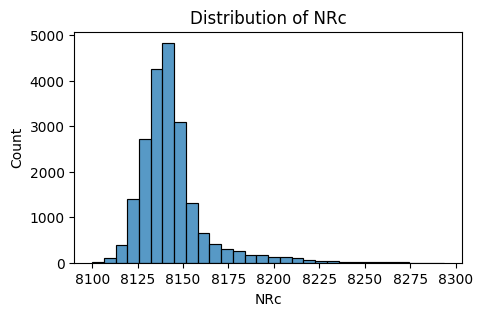

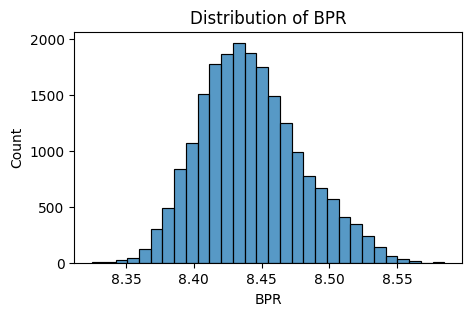

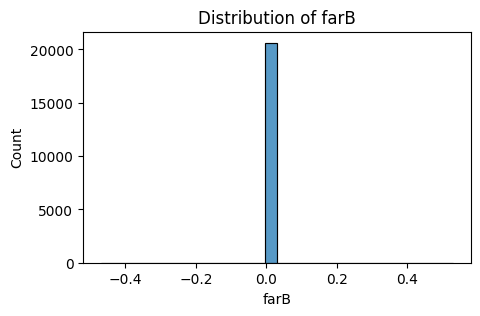

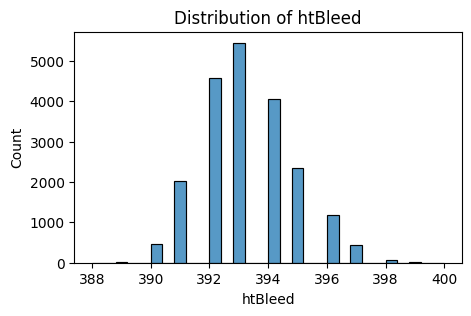

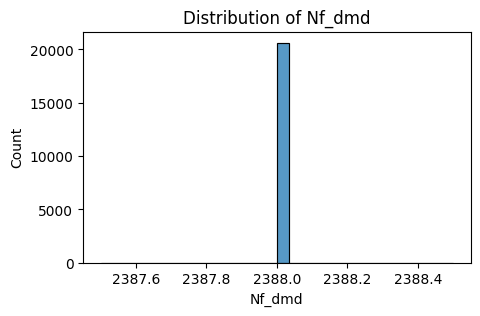

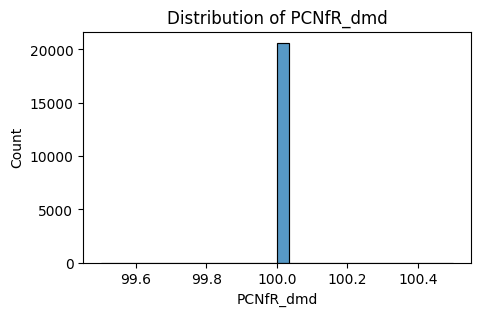

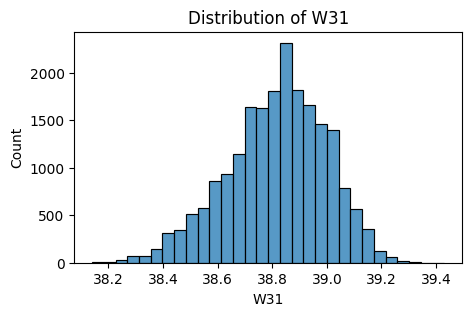

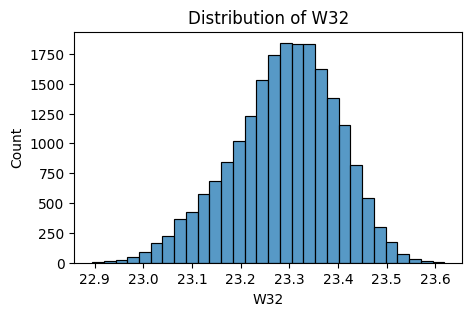

In [3]:
# STEP 3: EDA - HISTOGRAMS
# Understand distribution of each sensor

for col in data.columns:
    plt.figure(figsize=(5,3))
    sns.histplot(data[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

In [4]:
# STEP 4: DATA PREPROCESSING
# Handle missing values
data = data.ffill()

# Drop unnecessary features
data.drop(columns=[
    'Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'], inplace=True)



In [5]:
# STEP 5: NORMALIZATION
sensor_data = data.drop(columns=['unit_number','time_in_cycles'])

scaler = MinMaxScaler()
sensor_scaled = scaler.fit_transform(sensor_data)

sensor_scaled = pd.DataFrame(sensor_scaled, columns=sensor_data.columns)



In [6]:
# STEP 6: SEQUENCE CREATION
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data.iloc[i:i+seq_length].values)
    return np.array(sequences)

sequence_length = 30
X_sequences = create_sequences(sensor_scaled, sequence_length)

print("Shape:", X_sequences.shape)

Shape: (20601, 30, 17)


In [7]:
# STEP 7: TIME-SERIES SPLIT
split = int(0.8 * len(X_sequences))

X_train = X_sequences[:split]
X_test = X_sequences[split:]

In [8]:
# STEP 8: MODEL BUILDING
timesteps = X_train.shape[1]
features = X_train.shape[2]

input_layer = Input(shape=(timesteps, features))

# Encoder
encoded = LSTM(64, activation='relu', return_sequences=False)(input_layer)

# Latent space
latent = RepeatVector(timesteps)(encoded)

# Decoder
decoded = LSTM(64, activation='relu', return_sequences=True)(latent)

# Output
output_layer = TimeDistributed(Dense(features))(decoded)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 17)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 17)         │         1,105 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,121 (215.32 KB)

 Trainable params: 55,121 (215.32 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# STEP 9: TRAIN MODEL
history = model.fit(X_train, X_train, epochs=5, batch_size=64, validation_data=(X_test, X_test),shuffle=False)

Epoch 1/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - loss: 0.0312 - val_loss: 0.0145
Epoch 2/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - loss: 0.0133 - val_loss: 0.0122
Epoch 3/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - loss: 0.0126 - val_loss: 0.0117
Epoch 4/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - loss: 0.0124 - val_loss: 0.0118
Epoch 5/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - loss: 0.0126 - val_loss: 0.0158


In [10]:
# STEP 10: RECONSTRUCTION ERROR
X_pred = model.predict(X_test)

reconstruction_error = np.mean(np.power(X_test - X_pred, 2),axis=(1,2))

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step


In [11]:
# STEP 11: HEALTH INDEX
error_min = reconstruction_error.min()
error_max = reconstruction_error.max()

health_index = 1 - ((reconstruction_error - error_min) / (error_max - error_min))

health_index = np.clip(health_index, 0, 1)

health_index_smooth = pd.Series(health_index).rolling(window=10, min_periods=1).mean()

In [12]:
# STEP 12: ADD HEALTH INDEX TO DATA
test_start = split + sequence_length

data["Health_Index"] = np.nan
data.loc[test_start:test_start + len(health_index) - 1, "Health_Index"] = health_index

data["Health_Index_Smoothed"] = np.nan
data.loc[test_start:test_start + len(health_index_smooth) - 1, "Health_Index_Smoothed"] = health_index_smooth.values



In [13]:
# # Calculate correct starting index
# test_start = split + sequence_length

# # Create empty columns
# data["Health_Index"] = np.nan
# data["Health_Index_Smoothed"] = np.nan

# # Assign values only to test portion
# data.iloc[test_start:test_start + len(health_index),data.columns.get_loc("Health_Index")] = health_index

# data.iloc[test_start:test_start + len(health_index_smooth),data.columns.get_loc("Health_Index_Smoothed")] = health_index_smooth.values
# def health_condition(hi):
#     if hi >= 0.8:
#         return "GOOD"
#     elif hi >= 0.5:
#         return "MODERATE"
#     else:
#         return "BAD"
# status = "good"                  # change to GOOD / MODERATE

# filtered_data = data[data["Condition"] == status]

# print(filtered_data[[
#     "unit_number",
#     "time_in_cycles",
#     "Health_Index",
#     "Condition"
# ]].head(20))

# data.tail(10)

In [14]:
# Calculate correct starting index
test_start = split + sequence_length

# Create columns
data["Health_Index"] = np.nan
data["Health_Index_Smoothed"] = np.nan

# Assign values
data.iloc[test_start:test_start + len(health_index),data.columns.get_loc("Health_Index")] = health_index

data.iloc[test_start:test_start + len(health_index_smooth),data.columns.get_loc("Health_Index_Smoothed")] = health_index_smooth.values


# Define condition logic
def health_condition(hi):
    if hi >= 0.8:
        return "GOOD"
    elif hi >= 0.5:
        return "MODERATE"
    else:
        return "BAD"


data["Condition"] = data["Health_Index"].apply(lambda x: health_condition(x) if pd.notnull(x) else np.nan)

status = "GOOD"   # not "good"


# Filter
filtered_data = data[data["Condition"] == status]


# Display
print(filtered_data[["unit_number","time_in_cycles","Health_Index","Condition"]].head(20))

print(data.tail(10))

       unit_number  time_in_cycles  Health_Index Condition
16520           82             143      0.802203      GOOD
16521           82             144      0.801688      GOOD
16523           82             146      0.800176      GOOD
16524           82             147      0.801721      GOOD
16525           82             148      0.800554      GOOD
16526           82             149      0.806190      GOOD
16527           82             150      0.806418      GOOD
16528           82             151      0.813247      GOOD
16529           82             152      0.820108      GOOD
16530           82             153      0.828307      GOOD
16531           82             154      0.847417      GOOD
16532           82             155      0.865695      GOOD
16533           82             156      0.886246      GOOD
16534           82             157      0.908309      GOOD
16535           82             158      0.903787      GOOD
16536           82             159      0.910523      GO

In [15]:
# # Step 9: Debug (option
print("\nAvailable Conditions:", data["Condition"].unique())
print("\nCondition Counts:\n", data["Condition"].value_counts())


# Step 10: View dataset tail
print("\nLast 10 rows:")
print(data.tail(10))
print(data["Condition"].value_counts())



Available Conditions: [nan 'MODERATE' 'GOOD' 'BAD']

Condition Counts:
 Condition
GOOD        3480
MODERATE     479
BAD          162
Name: count, dtype: int64

Last 10 rows:
       unit_number  time_in_cycles  setting_1  setting_2     T24      T30  \
20621          100             191    -0.0005    -0.0000  643.69  1610.87   
20622          100             192    -0.0009     0.0001  643.53  1601.23   
20623          100             193    -0.0001     0.0002  643.09  1599.81   
20624          100             194    -0.0011     0.0003  643.72  1597.29   
20625          100             195    -0.0002    -0.0001  643.41  1600.04   
20626          100             196    -0.0004    -0.0003  643.49  1597.98   
20627          100             197    -0.0016    -0.0005  643.54  1604.50   
20628          100             198     0.0004     0.0000  643.42  1602.46   
20629          100             199    -0.0011     0.0003  643.23  1605.26   
20630          100             200    -0.0032    -0.000

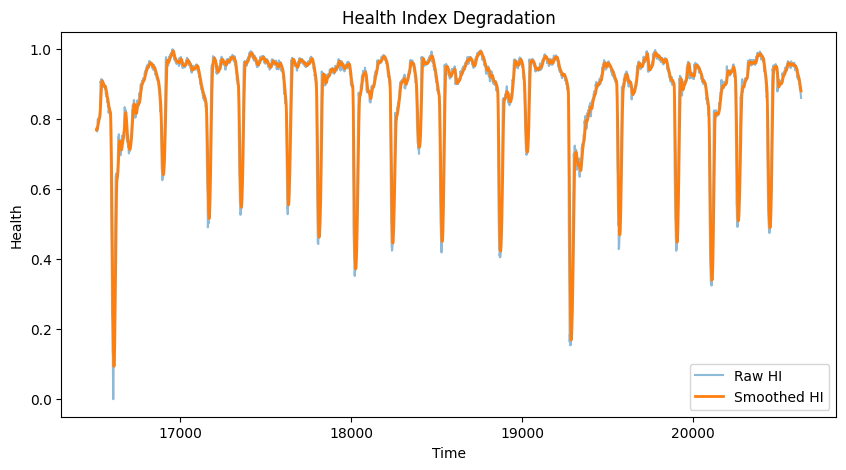

In [16]:
# STEP 13: VISUALIZATION
plt.figure(figsize=(10,5))

plt.plot(data["Health_Index"], label="Raw HI", alpha=0.5)
plt.plot(data["Health_Index_Smoothed"], label="Smoothed HI", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Health")
plt.title("Health Index Degradation")

plt.legend()
plt.show()

In [17]:
# # FULL PIPELINE

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
# from tensorflow.keras.optimizers import Adam

# data = pd.read_csv(r"C:\Users\Chekk\OneDrive\Desktop\Major_Project\Machine_Learning_Project\train_FD001.txt", sep=" ", header=None)
# data.drop(columns=[26,27], inplace=True)

# columns = [
# 'unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50',
# 'P2','P15','P30','Nf','Nc','epr','Ps30','phi','NRf','NRc','BPR','farB',
# 'htBleed','Nf_dmd','PCNfR_dmd','W31','W32'
# ]
# data.columns = columns

# data = data.ffill()

# data.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'], inplace=True)

# sensor_data = data.drop(columns=['unit_number','time_in_cycles'])

# scaler = MinMaxScaler()
# sensor_scaled = scaler.fit_transform(sensor_data)
# sensor_scaled = pd.DataFrame(sensor_scaled, columns=sensor_data.columns)

# def create_sequences(data, seq_length):
#     sequences = []
#     for i in range(len(data) - seq_length):
#         sequences.append(data.iloc[i:i+seq_length].values)
#     return np.array(sequences)

# sequence_length = 30
# X_sequences = create_sequences(sensor_scaled, sequence_length)

# split = int(0.8 * len(X_sequences))
# X_train = X_sequences[:split]
# X_test = X_sequences[split:]

# timesteps = X_train.shape[1]
# features = X_train.shape[2]

# input_layer = Input(shape=(timesteps, features))
# encoded = LSTM(64, activation='relu', return_sequences=False)(input_layer)
# latent = RepeatVector(timesteps)(encoded)
# decoded = LSTM(64, activation='relu', return_sequences=True)(latent)
# output_layer = TimeDistributed(Dense(features))(decoded)

# model = Model(inputs=input_layer, outputs=output_layer)
# model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# model.fit(X_train, X_train, epochs=10, batch_size=64, validation_data=(X_test, X_test), shuffle=False)

# X_pred = model.predict(X_test)

# reconstruction_error = np.mean(np.power(X_test - X_pred, 2), axis=(1,2))

# error_min = reconstruction_error.min()
# error_max = reconstruction_error.max()

# health_index = 1 - ((reconstruction_error - error_min) / (error_max - error_min))
# health_index = np.clip(health_index, 0, 1)

# health_index_smooth = pd.Series(health_index).rolling(window=10, min_periods=1).mean()

# data["Health_Index"] = np.nan
# data.loc[sequence_length:, "Health_Index"] = health_index

# data["Health_Index_Smoothed"] = np.nan
# data.loc[sequence_length:, "Health_Index_Smoothed"] = health_index_smooth.values

# plt.figure(figsize=(10,5))
# plt.plot(data["Health_Index"], label="Raw HI", alpha=0.5)
# plt.plot(data["Health_Index_Smoothed"], label="Smoothed HI", linewidth=2)
# plt.legend()
# plt.show()

## Test_Data

In [ ]:
# STEP 1: LOAD TEST DATA

test_data = pd.read_csv(
    r"C:\Users\Chekk\OneDrive\Desktop\Major_Project\Machine_Learning_Project\test_FD001.txt",
    sep=" ",
    header=None
)

test_data.drop(columns=[26, 27], inplace=True)

columns = [
    'unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50',
    'P2','P15','P30','Nf','Nc','epr','Ps30','phi','NRf','NRc','BPR','farB',
    'htBleed','Nf_dmd','PCNfR_dmd','W31','W32'
]

test_data.columns = columns

In [19]:
# Handle missing values
test_data = test_data.ffill()

# Drop same columns (IMPORTANT consistency)
test_data.drop(columns=[
    'Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'
], inplace=True)

In [20]:
sensor_test = test_data.drop(columns=['unit_number','time_in_cycles'])

sensor_test_scaled = scaler.transform(sensor_test)

sensor_test_scaled = pd.DataFrame(sensor_test_scaled, columns=sensor_test.columns)


In [21]:
scaler.fit_transform(test_data)

array([[0.        , 0.        , 0.65625   , ..., 0.375     , 0.5       ,
        0.62009908],
       [0.        , 0.00331126, 0.34375   , ..., 0.5       , 0.64545455,
        0.64571833],
       [0.        , 0.00662252, 0.53125   , ..., 0.5       , 0.7       ,
        0.68110403],
       ...,
       [1.        , 0.64569536, 0.475     , ..., 0.75      , 0.28181818,
        0.38174098],
       [1.        , 0.64900662, 0.275     , ..., 0.75      , 0.31818182,
        0.47346072],
       [1.        , 0.65231788, 0.59375   , ..., 0.875     , 0.35454545,
        0.35399858]], shape=(13096, 19))

In [22]:
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data.iloc[i:i+seq_length].values)
    return np.array(sequences)

sequence_length = 30

X_test_seq = create_sequences(sensor_test_scaled, sequence_length)

print("Test Shape:", X_test_seq.shape)

Test Shape: (13066, 30, 17)


In [23]:
X_test_pred = model.predict(X_test_seq)

409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step


In [24]:
reconstruction_error_test = np.mean(
    np.power(X_test_seq - X_test_pred, 2),
    axis=(1,2)
)

In [25]:
health_index_test = 1 - (
    (reconstruction_error_test - error_min) /
    (error_max - error_min)
)

health_index_test = np.clip(health_index_test, 0, 1)

health_index_test_smooth = pd.Series(health_index_test).rolling(
    window=10, min_periods=1
).mean()

In [26]:
test_data["Health_Index"] = np.nan
test_data["Health_Index_Smoothed"] = np.nan

test_data.loc[
    sequence_length:sequence_length + len(health_index_test) - 1,
    "Health_Index"
] = health_index_test

test_data.loc[
    sequence_length:sequence_length + len(health_index_test_smooth) - 1,
    "Health_Index_Smoothed"
] = health_index_test_smooth.values

In [27]:
def health_condition(hi):
    if hi >= 0.8:
        return "GOOD"
    elif hi >= 0.5:
        return "MODERATE"
    else:
        return "BAD"

test_data["Condition"] = test_data["Health_Index"].apply(
    lambda x: health_condition(x) if pd.notnull(x) else np.nan
)

In [31]:
status = "GOOD"   # change to GOOD / MODERATE / BAD

filtered_test = test_data[test_data["Condition"] == status]

print(filtered_test[[
    "unit_number",
    "time_in_cycles",
    "Health_Index",
    "Condition"
]].head(20))

    unit_number  time_in_cycles  Health_Index Condition
30            1              31      0.931700      GOOD
31            2               1      0.934571      GOOD
32            2               2      0.935255      GOOD
33            2               3      0.938399      GOOD
34            2               4      0.938807      GOOD
35            2               5      0.940231      GOOD
36            2               6      0.937091      GOOD
37            2               7      0.931759      GOOD
38            2               8      0.930199      GOOD
39            2               9      0.935506      GOOD
40            2              10      0.936231      GOOD
41            2              11      0.938678      GOOD
42            2              12      0.946112      GOOD
43            2              13      0.951700      GOOD
44            2              14      0.956954      GOOD
45            2              15      0.956055      GOOD
46            2              16      0.954938   

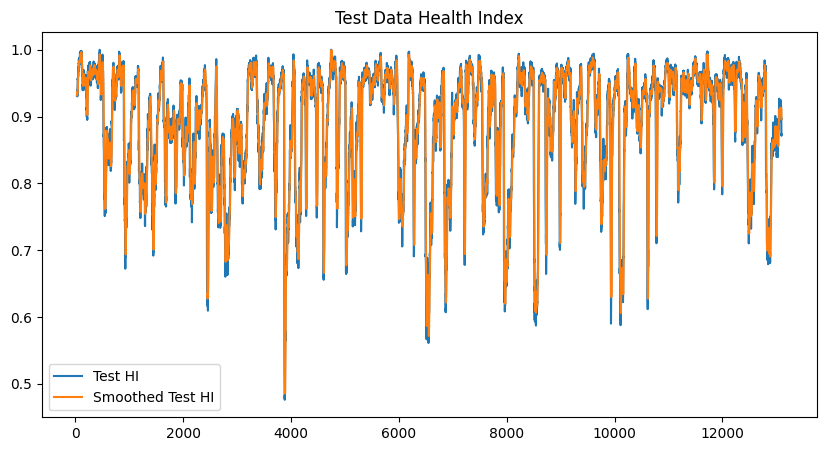

In [29]:
plt.figure(figsize=(10,5))

plt.plot(test_data["Health_Index"], label="Test HI")
plt.plot(test_data["Health_Index_Smoothed"], label="Smoothed Test HI")

plt.title("Test Data Health Index")
plt.legend()
plt.show()

In [30]:

# # ========================
# # 10. LOAD TEST DATA
# # ========================
# test_data = pd.read_csv(
#     r"C:\Users\Chekk\OneDrive\Desktop\Major_Project\Machine_Learning_Project\test_FD001.txt",
#     sep=" ",
#     header=None
# )

# test_data.drop(columns=[26,27], inplace=True)
# test_data.columns = columns


# # ========================
# # 11. PREPROCESS TEST
# # ========================
# test_data = test_data.ffill()

# test_data.drop(columns=[
# 'Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'
# ], inplace=True)


# # ========================
# # 12. NORMALIZE TEST
# # ========================
# sensor_test = test_data.drop(columns=['unit_number','time_in_cycles'])

# sensor_test_scaled = scaler.transform(sensor_test)

# sensor_test_scaled = pd.DataFrame(sensor_test_scaled, columns=sensor_test.columns)


# # ========================
# # 13. CREATE TEST SEQUENCES
# # ========================
# X_test_seq = create_sequences(sensor_test_scaled, sequence_length)


# # ========================
# # 14. PREDICT
# # ========================
# X_test_pred = model.predict(X_test_seq)


# # ========================
# # 15. RECONSTRUCTION ERROR
# # ========================
# reconstruction_error_test = np.mean(
#     np.power(X_test_seq - X_test_pred, 2),
#     axis=(1,2)
# )


# # ========================
# # 16. HEALTH INDEX
# # ========================
# health_index_test = 1 - (
#     (reconstruction_error_test - error_min) /
#     (error_max - error_min)
# )

# health_index_test = np.clip(health_index_test, 0, 1)

# health_index_test_smooth = pd.Series(health_index_test).rolling(
#     window=10, min_periods=1
# ).mean()


# # ========================
# # 17. ADD TO TEST DATA
# # ========================
# test_data["Health_Index"] = np.nan
# test_data["Health_Index_Smoothed"] = np.nan

# test_data.loc[
#     sequence_length:sequence_length + len(health_index_test) - 1,
#     "Health_Index"
# ] = health_index_test

# test_data.loc[
#     sequence_length:sequence_length + len(health_index_test_smooth) - 1,
#     "Health_Index_Smoothed"
# ] = health_index_test_smooth.values


# # ========================
# # 18. CONDITION
# # ========================
# def health_condition(hi):
#     if hi >= 0.8:
#         return "GOOD"
#     elif hi >= 0.5:
#         return "MODERATE"
#     else:
#         return "BAD"

# test_data["Condition"] = test_data["Health_Index"].apply(
#     lambda x: health_condition(x) if pd.notnull(x) else np.nan
# )


# # ========================
# # 19. FILTER
# # ========================
# status = "BAD"

# filtered_test = test_data[test_data["Condition"] == status]

# print(filtered_test[[
#     "unit_number",
#     "time_in_cycles",
#     "Health_Index",
#     "Condition"
# ]].head(20))


# # ========================
# # 20. VISUALIZATION
# # ========================
# plt.figure(figsize=(10,5))

# plt.plot(test_data["Health_Index"], label="Test HI")
# plt.plot(test_data["Health_Index_Smoothed"], label="Smoothed HI")

# plt.title("Test Data Health Index")
# plt.legend()
# plt.show()